In [73]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [74]:
df = pd.read_csv("Mall_Customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [75]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

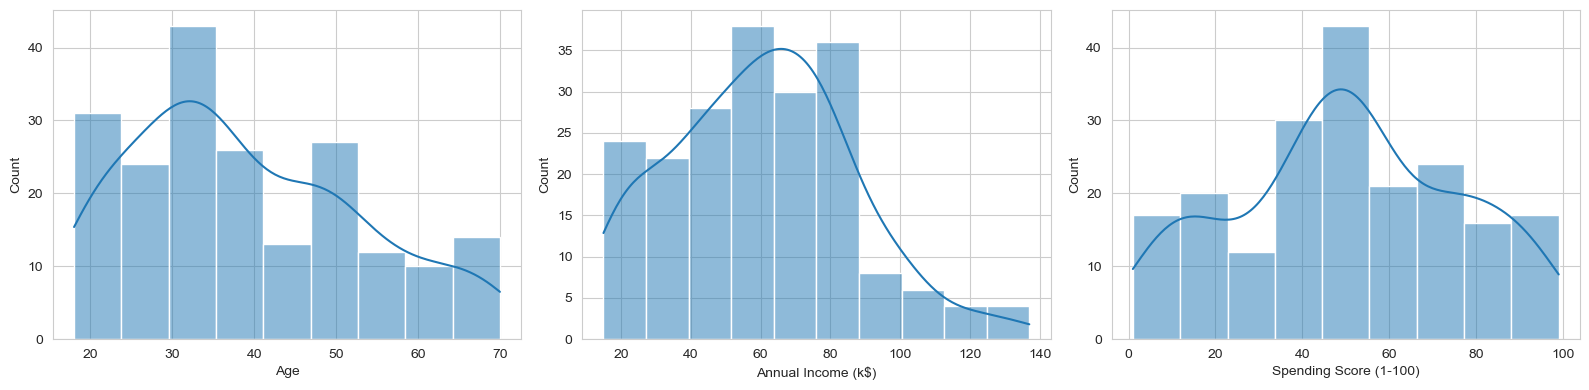

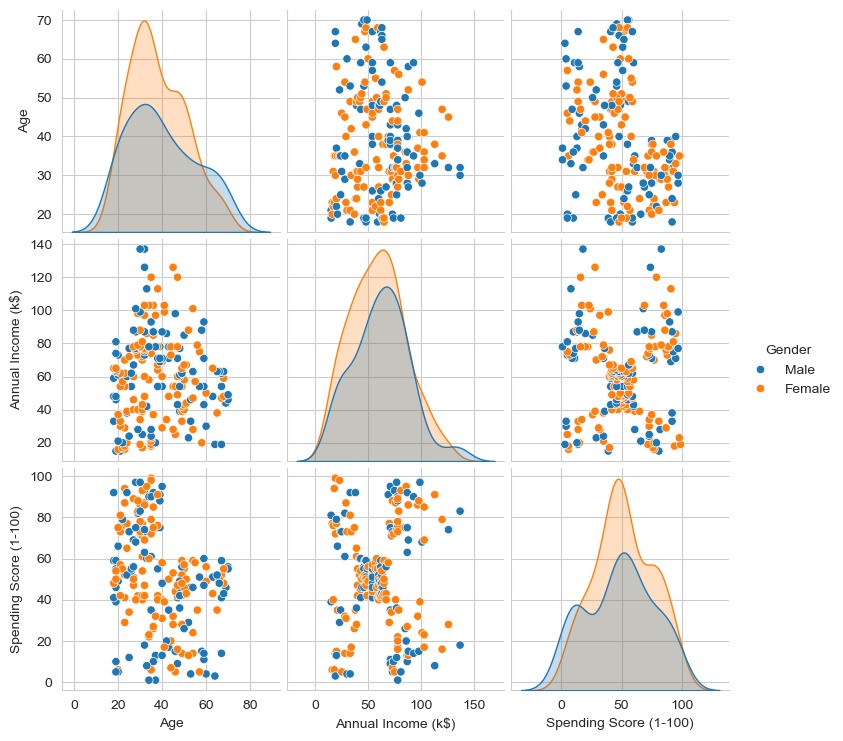

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0])
sns.histplot(df["Annual Income (k$)"], kde=True, ax=axes[1])
sns.histplot(df["Spending Score (1-100)"], kde=True, ax=axes[2])
plt.tight_layout()
plt.show()

sns.pairplot(df[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender"]], hue="Gender")
plt.show()

In [77]:
df_proc = df.copy()

le = LabelEncoder()
df_proc["Gender_enc"] = le.fit_transform(df_proc["Gender"])

feature_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender_enc"]
X_raw = df_proc[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(X_scaled.shape, pca.explained_variance_ratio_)

(200, 4) [0.33690046 0.26230645]


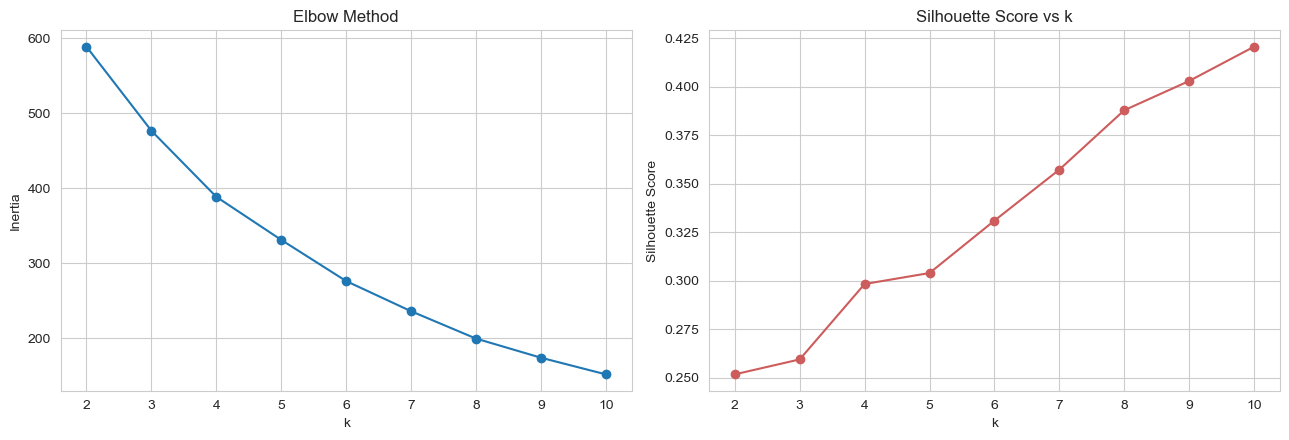

k=2: silhouette=0.252
k=3: silhouette=0.260
k=4: silhouette=0.298
k=5: silhouette=0.304
k=6: silhouette=0.331
k=7: silhouette=0.357
k=8: silhouette=0.388
k=9: silhouette=0.403
k=10: silhouette=0.421


In [78]:
# ===== K-Means =====
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, "-o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, "-o", color="indianred")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

In [79]:
K_OPTIMAL = 5

kmeans = KMeans(n_clusters=K_OPTIMAL, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df_proc["KMeans_Cluster"] = kmeans_labels

kmeans_inertia = kmeans.inertia_
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"Inertia: {kmeans_inertia:.2f}")
print(f"Silhouette: {kmeans_silhouette:.3f}")
print(f"Davies-Bouldin: {kmeans_db:.3f}")

Inertia: 331.31
Silhouette: 0.304
Davies-Bouldin: 1.167


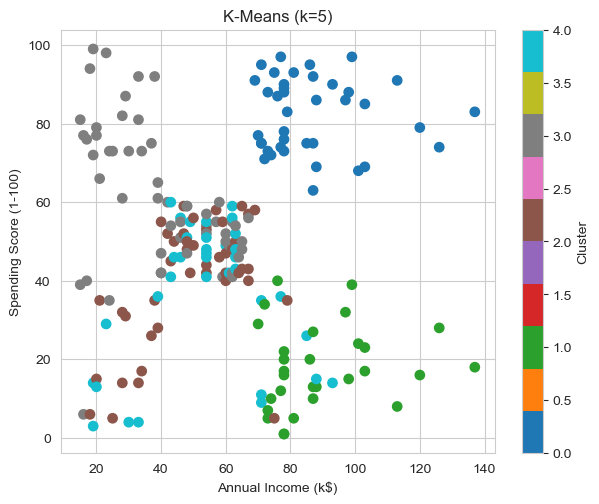

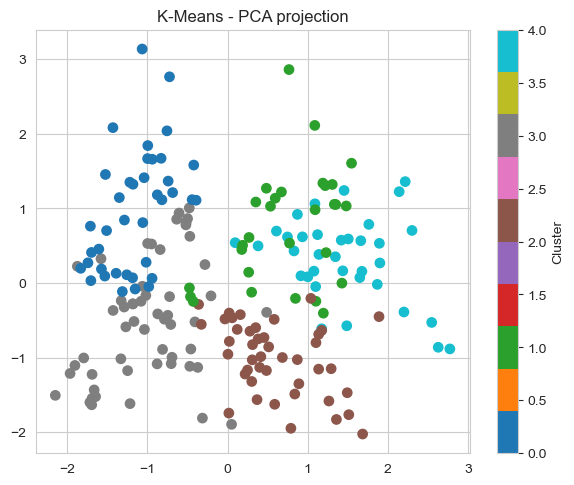

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,32.7,86.5,82.1
1,36.5,89.5,18.0
2,49.8,49.2,40.1
3,24.9,39.7,61.2
4,55.7,53.7,36.8


In [80]:
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=kmeans_labels, cmap="tab10", s=45)
plt.title(f"K-Means (k={K_OPTIMAL})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(sc, label="Cluster")
plt.show()

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="tab10", s=45)
plt.title("K-Means - PCA projection")
plt.colorbar(sc, label="Cluster")
plt.show()

df_proc.groupby("KMeans_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

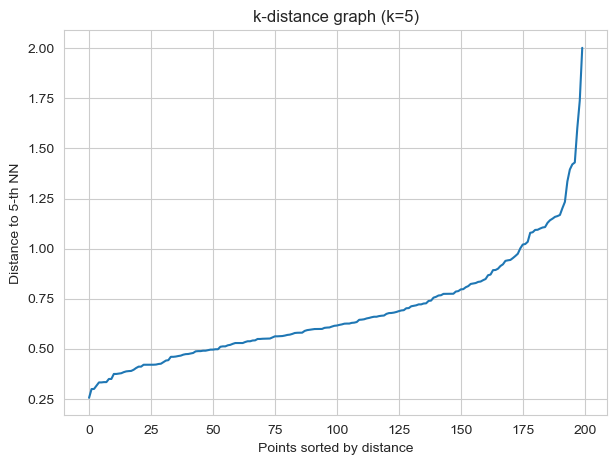

In [81]:
# ===== DBSCAN =====
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
distances, _ = neighbors.fit(X_scaled).kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title(f"k-distance graph (k={min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th NN")
plt.show()

In [82]:
EPS_OPTIMAL = 0.8
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS_OPTIMAL, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)
df_proc["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Clusters: {n_clusters_db}, Noise: {n_noise} ({n_noise/len(dbscan_labels):.1%})")

if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_db_score = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    print(f"Silhouette (excl. noise): {dbscan_silhouette:.3f}")
    print(f"Davies-Bouldin (excl. noise): {dbscan_db_score:.3f}")
else:
    dbscan_silhouette = np.nan
    dbscan_db_score = np.nan

Clusters: 5, Noise: 19 (9.5%)
Silhouette (excl. noise): 0.227
Davies-Bouldin (excl. noise): 1.082


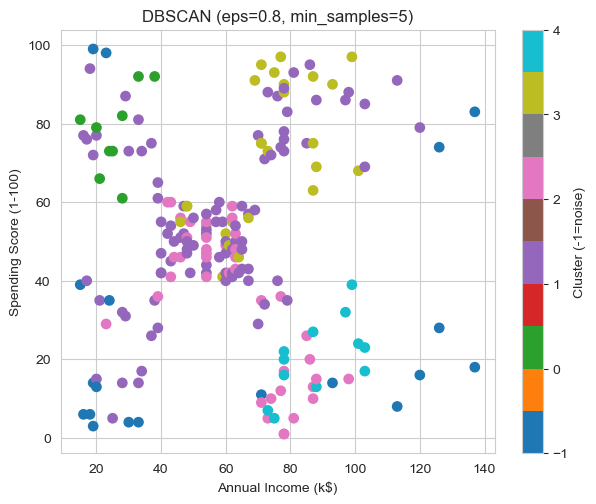

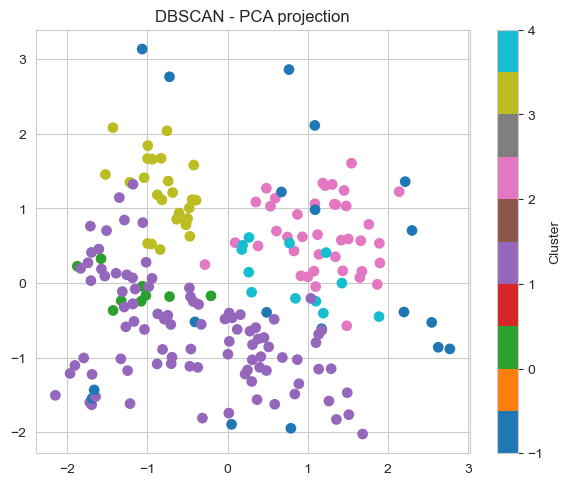

,Age,Annual Income (k$),Spending Score (1-100)
DBSCAN_Cluster,,,
-1,41.9,61.0,30.2
0,25.0,25.8,77.7
1,37.5,55.9,56.1
2,48.6,63.3,34.8
3,29.0,72.1,71.4
4,43.4,88.3,20.4


In [83]:
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=dbscan_labels, cmap="tab10", s=45)
plt.title(f"DBSCAN (eps={EPS_OPTIMAL}, min_samples={MIN_SAMPLES})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(sc, label="Cluster (-1=noise)")
plt.show()

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="tab10", s=45)
plt.title("DBSCAN - PCA projection")
plt.colorbar(sc, label="Cluster")
plt.show()

df_proc.groupby("DBSCAN_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

In [84]:
# ===== Mean-Shift =====
bandwidth = estimate_bandwidth(X_scaled, quantile=0.1, n_samples=len(X_scaled), random_state=42)
print(f"Bandwidth: {bandwidth:.3f}")

meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
meanshift_labels = meanshift.fit_predict(X_scaled)
df_proc["MeanShift_Cluster"] = meanshift_labels

n_clusters_ms = len(np.unique(meanshift_labels))
meanshift_silhouette = silhouette_score(X_scaled, meanshift_labels) if n_clusters_ms >= 2 else np.nan
meanshift_db_score = davies_bouldin_score(X_scaled, meanshift_labels) if n_clusters_ms >= 2 else np.nan

print(f"Clusters: {n_clusters_ms}")
print(f"Silhouette: {meanshift_silhouette:.3f}")
print(f"Davies-Bouldin: {meanshift_db_score:.3f}")

Bandwidth: 1.460
Clusters: 5
Silhouette: 0.280
Davies-Bouldin: 1.076


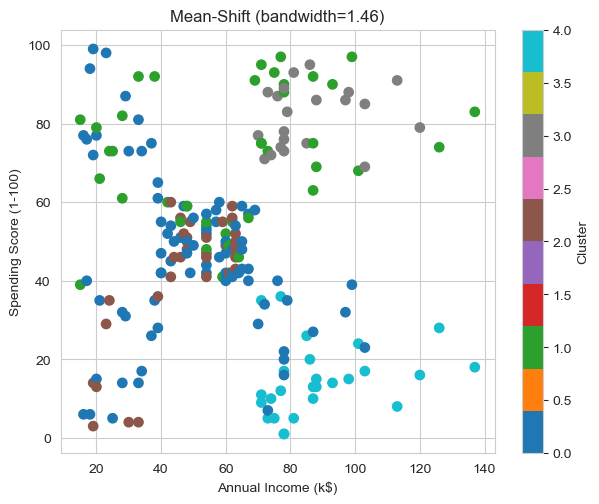

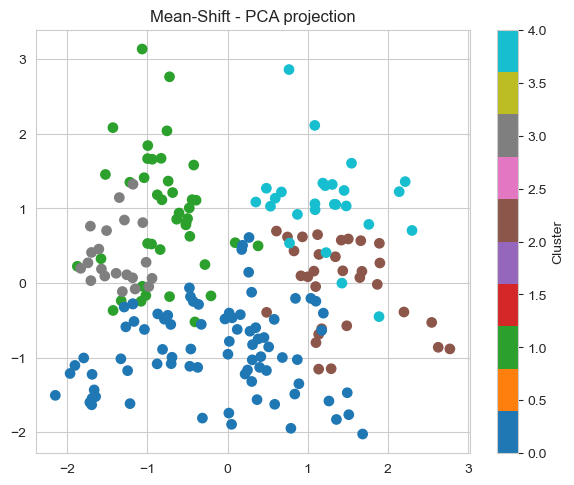

,Age,Annual Income (k$),Spending Score (1-100)
MeanShift_Cluster,,,
0,37.4,49.4,46.3
1,28.5,61.8,71.1
2,58.5,47.0,41.2
3,32.2,86.0,81.7
4,41.8,89.1,14.8


In [85]:
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=meanshift_labels, cmap="tab10", s=45)
plt.title(f"Mean-Shift (bandwidth={bandwidth:.2f})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(sc, label="Cluster")
plt.show()

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=meanshift_labels, cmap="tab10", s=45)
plt.title("Mean-Shift - PCA projection")
plt.colorbar(sc, label="Cluster")
plt.show()

df_proc.groupby("MeanShift_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

In [86]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN", "Mean-Shift"],
    "Num_Clusters": [K_OPTIMAL, n_clusters_db, n_clusters_ms],
    "Silhouette_Score": [kmeans_silhouette, dbscan_silhouette, meanshift_silhouette],
    "Davies_Bouldin": [kmeans_db, dbscan_db_score, meanshift_db_score],
    "Inertia": [kmeans_inertia, np.nan, np.nan],
    "Noise_Points": [0, n_noise, 0],
})
comparison

,Method,Num_Clusters,Silhouette_Score,Davies_Bouldin,Inertia,Noise_Points
0,K-Means,5,0.304060,1.167230,331.309884,0
1,DBSCAN,5,0.227260,1.081682,NaN,19
2,Mean-Shift,5,0.280262,1.076394,NaN,0


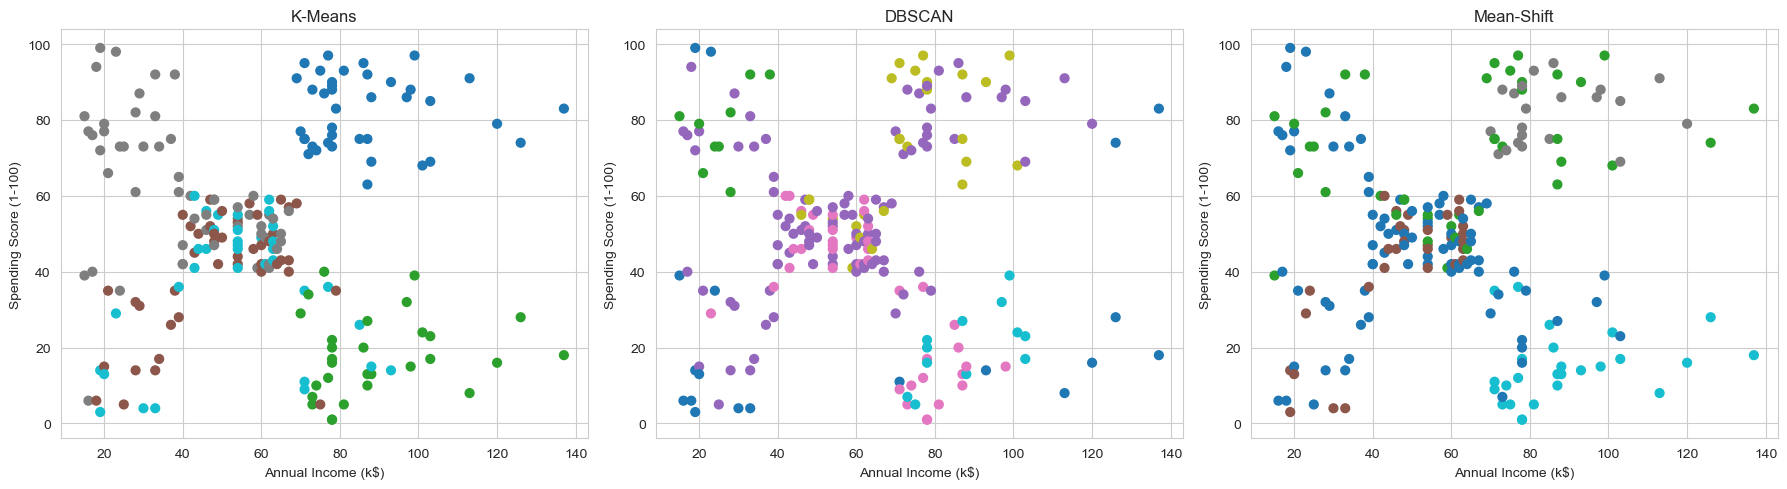

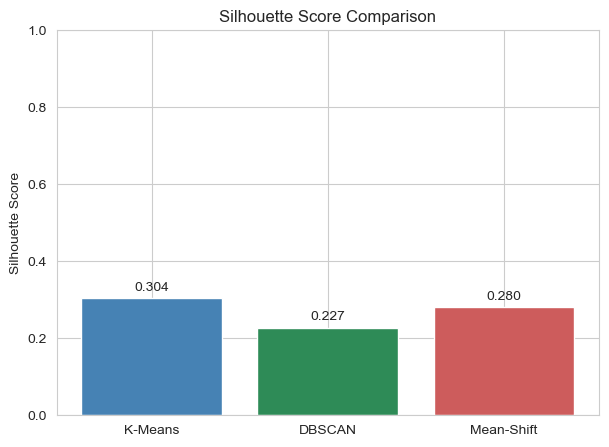

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_dict = {"K-Means": kmeans_labels, "DBSCAN": dbscan_labels, "Mean-Shift": meanshift_labels}

for ax, (name, labels) in zip(axes, labels_dict.items()):
    sc = ax.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=labels, cmap="tab10", s=40)
    ax.set_title(name)
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(comparison["Method"], comparison["Silhouette_Score"], color=["steelblue", "seagreen", "indianred"])
plt.title("Silhouette Score Comparison")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)
for i, v in enumerate(comparison["Silhouette_Score"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.show()